#  Customer Churn Prediction

Predicting customer churn using Machine Learning and Random Forest Classifier.

# 1-Import Libraries

In [128]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score, roc_curve
from sklearn.impute import SimpleImputer


# 2-Load Dataset

In [129]:
data=pd.read_csv('Customer-Churn.csv')


# 3-Data Exploration

In [130]:
data.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [131]:
data.info()
data.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [132]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [133]:
data.duplicated().sum()

np.int64(0)

# 4-Feature Selection and Data Cleaning

In [134]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data["Churn"] = data["Churn"].astype(str).str.strip().str.lower()
data["Churn"] = data["Churn"].map({"no":0, "yes":1})
data = data.drop("customerID", axis=1)
x=data.drop(["Churn"],axis=1)
y=data["Churn"]
   

# 5-Exploratory Data Analysis (EDA)

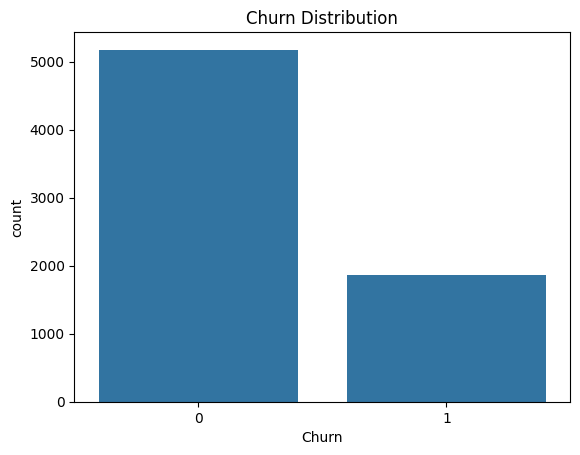

In [135]:
sns.countplot(x="Churn", data=data)
plt.title("Churn Distribution")
plt.show()

# 6-Data Preprocessing

In [136]:
x_train,x_test,y_train,y_test=train_test_split(x,
                                               y,
                                               test_size=0.2,
                                               random_state=42)
def fix_total_charges(x):
    x = x.copy()
    x["TotalCharges"] = pd.to_numeric(x["TotalCharges"], errors="coerce")
    return x

cat_cols = [
"gender","Partner","Dependents","PhoneService",
"MultipleLines","InternetService","OnlineSecurity",
"OnlineBackup","DeviceProtection","TechSupport",
"StreamingTV","StreamingMovies","Contract",
"PaperlessBilling","PaymentMethod"
]
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]



preprocess = ColumnTransformer([
    
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", numeric_transformer, num_cols)
]
)


# 7-Model Training and Prediction

In [137]:
rf_model = Pipeline([
  
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_split=8,
        min_samples_leaf=5,
        random_state=42,
        class_weight='balanced'
    ))
])

rf_model.fit(x_train, y_train)
#____model 2_____________

xgb = XGBClassifier(
    n_estimators=600,
    max_depth=5,
    learning_rate=0.02,
    scale_pos_weight=len(y_train[y_train==0]) / len(y_train[y_train==1]),  
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42
)

xgb_model = Pipeline([
 
    ("preprocess", preprocess),
    ("model", xgb)
])
xgb_model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [138]:
rf_pred = rf_model.predict(x_test)
xgb_pred = xgb_model.predict(x_test)

['model.pkl']

# 8-Model Evaluation

In [140]:
print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))

print("\nRF Report:\n", classification_report(y_test, rf_pred))
print("\nXGB Report:\n", classification_report(y_test, xgb_pred))

RF Accuracy: 0.759403832505323
XGB Accuracy: 0.7707594038325053

RF Report:
               precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.83      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409


XGB Report:
               precision    recall  f1-score   support

           0       0.91      0.76      0.83      1036
           1       0.55      0.80      0.65       373

    accuracy                           0.77      1409
   macro avg       0.73      0.78      0.74      1409
weighted avg       0.82      0.77      0.78      1409



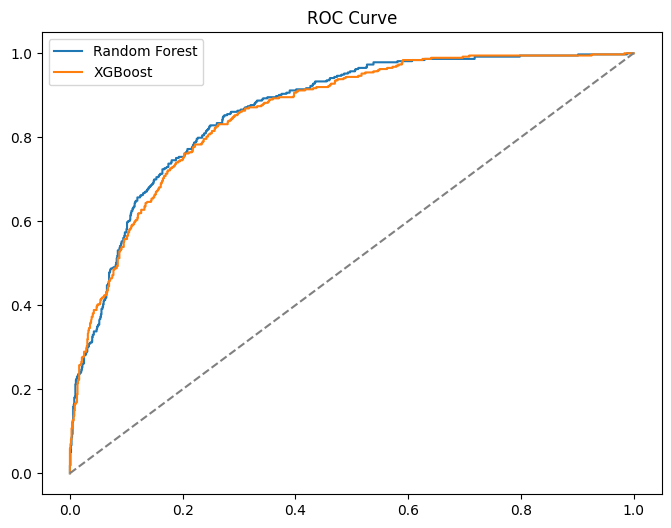

In [141]:
rf_prob = rf_model.predict_proba(x_test)[:,1]
xgb_prob = xgb_model.predict_proba(x_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")
plt.plot([0,1],[0,1],"--",color="gray")
plt.legend()
plt.title("ROC Curve")
plt.show()

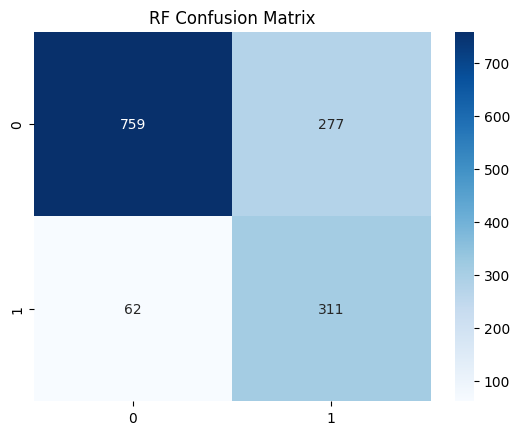

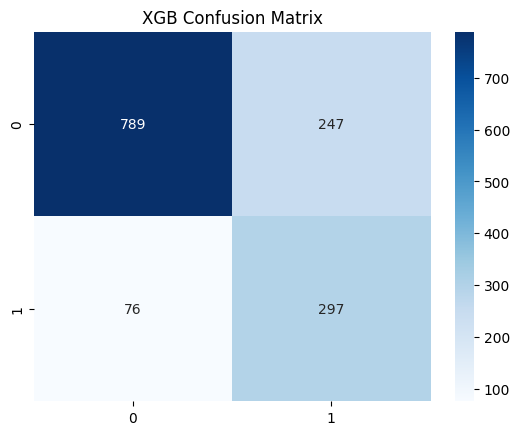

In [142]:
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d",cmap="Blues")
plt.title("RF Confusion Matrix")
plt.show()

sns.heatmap(confusion_matrix(y_test, xgb_pred), annot=True, fmt="d",cmap="Blues")
plt.title("XGB Confusion Matrix")
plt.show()

# 9-Feature Importance for XGBoost

In [148]:
features = xgb_model.named_steps["preprocess"].get_feature_names_out()
importances = xgb_model.named_steps["model"].feature_importances_

feature_names_clean = (
    pd.Index(features)
    .str.replace("cat__", "", regex=False)
    .str.replace("num__", "", regex=False)
)
feat_imp = pd.DataFrame({
    "Feature": feature_names_clean,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(feat_imp.head(10))

                           Feature  Importance
32         Contract_Month-to-month    0.370947
14               OnlineSecurity_No    0.073272
12     InternetService_Fiber optic    0.062102
34               Contract_Two year    0.044246
23                  TechSupport_No    0.036460
11             InternetService_DSL    0.036289
31             StreamingMovies_Yes    0.025667
33               Contract_One year    0.024719
7                 PhoneService_Yes    0.020052
9   MultipleLines_No phone service    0.019488


# 10-SHAP for XGBoost

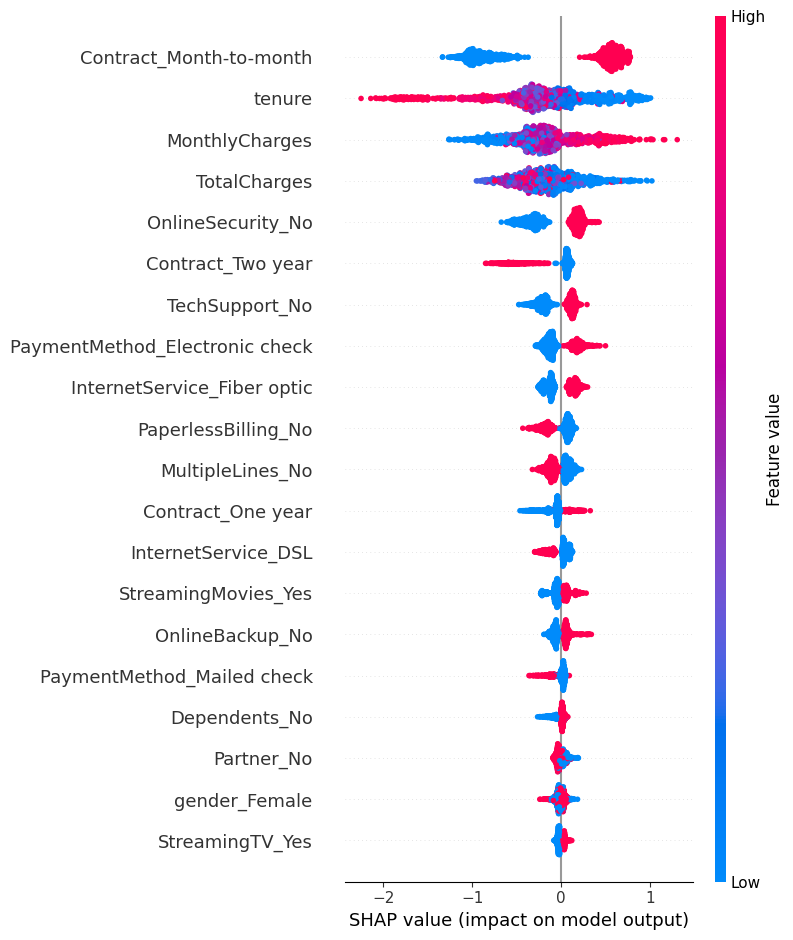

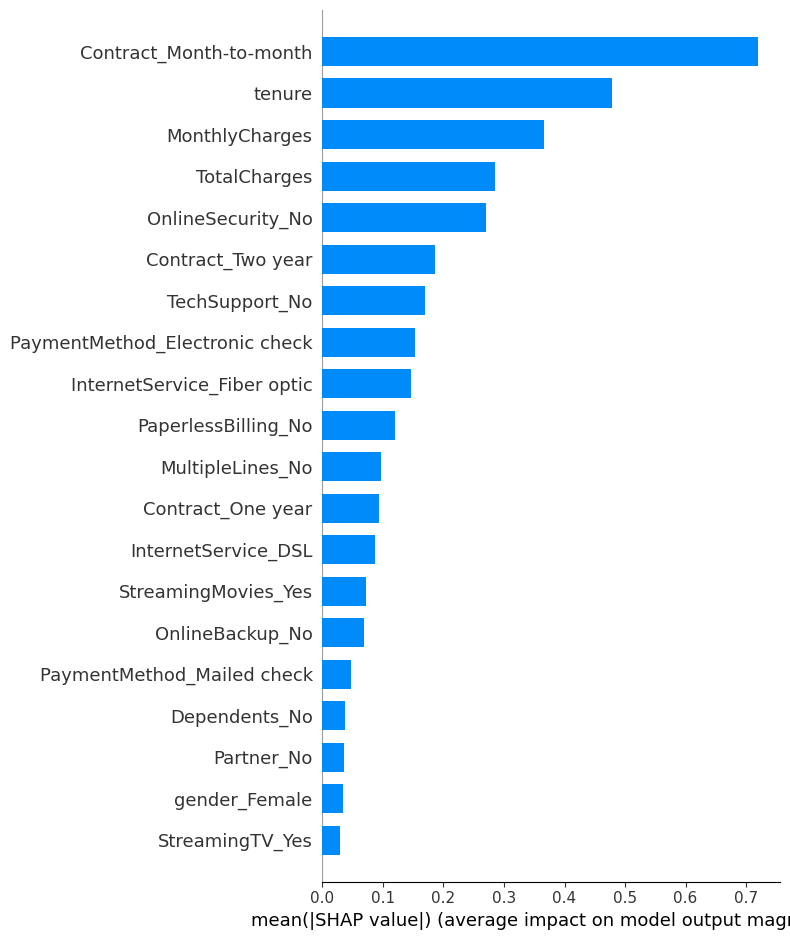

In [149]:
preprocessor = xgb_model.named_steps["preprocess"]
model = xgb_model.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
x_test_encoded = preprocessor.transform(x_test)

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(x_test_encoded)

shap.summary_plot(shap_values, x_test_encoded,feature_names=feature_names_clean)
shap.summary_plot(shap_values, x_test_encoded,feature_names=feature_names_clean, plot_type="bar")

# 11-save the model


In [150]:
joblib.dump(xgb_model, "model.pkl")

['model.pkl']

# 12-Business Insights (XGBoost Interpretation)

Based on the XGBoost model feature importance, customer churn is primarily driven by contract type, service adoption, and internet service quality.

1. Contract Type is the strongest churn driver  
Month-to-month contracts are the most important predictor of churn (importance ≈ 0.37). Customers on flexible contracts are significantly more likely to leave the company. In contrast, longer contracts (One year, Two year) reduce churn risk.  
Insight: Contract stability is the most critical factor in customer retention.

2. Lack of value-added services increases churn risk  
Customers without Online Security and Tech Support show higher churn tendency. These services act as retention boosters.  
Insight: Customers who are not engaged with support and security services are less likely to remain loyal.

3. Internet Service type matters  
Fiber optic users are more likely to churn compared to DSL users. DSL also appears as a moderate influencing factor.  
Insight: High-speed internet users may have higher expectations or greater price sensitivity.

4. Streaming services have minor influence  
StreamingMovies has lower but still noticeable importance. Entertainment services contribute slightly to retention but are not primary drivers of churn.

5. Phone and connectivity features have low impact  
PhoneService and MultipleLines have relatively low importance. These features are not strong churn predictors compared to contract or support-related features.

Key Business Interpretation  
Customer churn is mainly influenced by contract flexibility, customer engagement with support services, and type of internet service. The model shows that churn is strongly tied to customer commitment level and depth of service usage rather than basic connectivity features.



# 13-Business Recommendations

1. Reduce dependency on month-to-month contracts  
Encourage long-term contracts such as one-year and two-year plans through discounts, loyalty rewards, and bundled offers.

2. Improve early customer engagement  
Focus on customers in their first months (low tenure). Provide onboarding support and personalized retention offers.

3. Promote Online Security and Tech Support services  
Bundle these services with internet plans and offer free trials to increase adoption and reduce churn.

4. Investigate Fiber Optic churn behavior  
Analyze pricing, service quality, and customer expectations for fiber optic users to identify churn causes.

5. Build a churn early warning system  
Deploy the model to identify high-risk customers and trigger proactive retention actions such as discounts or targeted support.

Final Conclusion  
The XGBoost model indicates that customer churn is primarily driven by contract flexibility and service engagement level. Customers on month-to-month contracts with low usage of support and security services are the most likely to churn. These insights can help the business design targeted retention strategies focused on contract optimization, service bundling, and customer engagement.

# 14-Conclusion

The XGBoost model indicates that customer churn is primarily driven by contract flexibility and service engagement level. Customers on month-to-month contracts with low usage of support and security services are the most likely to churn. These insights can help the business design targeted retention strategies focused on contract optimization, service bundling, and customer engagement.